# Windowed SVM AMP sigma-score activations

This notebook accepts the **per-window** CSV produced by `scripts/svm/svm_predict_windowed.py`. It converts overlapping `SVM_hyperplane_distance` values into a per-residue score and draws colored sigma-score activation bars (where >0 is membrane-active/AMP and <0 is non-membrane-active).

It previews every parent sequence and saves one image per sequence.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- experiment configuration ---
INPUT_CSV = "../sequence_to_svm_minimal/data/test/piezo1/generated/piezo1_svm_window_predictions.csv"
OUTPUT_DIR = "../sequence_to_svm_minimal/data/test/histones/svm_sigma_heatmaps"

PREVIEW_COLUMNS = 4
PREVIEW_ROW_HEIGHT = 2.8
SAVE_IMAGES = True
SAVE_DPI = 200
HEATMAP_CMAP = "viridis"
SIGMA_LIMIT = 3.5

## Plotting helpers

Safe to ignore after running once.

In [5]:
def _resolve_path(value: str | Path) -> Path:
    raw = Path(value).expanduser()
    if raw.is_absolute():
        return raw
    for candidate in (Path.cwd() / raw, Path.cwd() / "notebooks" / raw):
        if candidate.exists():
            return candidate.resolve()
    return (Path.cwd() / raw).resolve()


def load_window_predictions() -> pd.DataFrame:
    csv_path = _resolve_path(INPUT_CSV)
    if not csv_path.is_file():
        raise FileNotFoundError(f"Window prediction CSV not found: {csv_path}")
    frame = pd.read_csv(csv_path)
    required = {
        "parent_id",
        "parent_sequence_length",
        "window_start",
        "window_end",
        "SVM_hyperplane_distance",
    }
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"Input CSV is missing columns: {sorted(missing)}")
    if frame.empty:
        raise ValueError("Input CSV is empty.")
    return frame


def sigma_profile(sequence_windows: pd.DataFrame) -> np.ndarray:
    length = int(sequence_windows["parent_sequence_length"].iloc[0])
    totals = np.zeros(length, dtype=float)
    coverage = np.zeros(length, dtype=int)
    for window in sequence_windows.itertuples(index=False):
        start, end = int(window.window_start), int(window.window_end)
        if start < 0 or end > length or start >= end:
            raise ValueError(f"Invalid window interval [{start}, {end}) for length {length}.")
        totals[start:end] += float(window.SVM_hyperplane_distance)
        coverage[start:end] += 1
    sigma = np.divide(
        totals, coverage, out=np.full(length, np.nan), where=coverage > 0
    )
    return sigma


def parent_label(parent_id: str, sequence_windows: pd.DataFrame) -> str:
    if "name" in sequence_windows.columns:
        name = str(sequence_windows["name"].iloc[0]).strip()
        if name and name.lower() != "nan":
            return name
    return parent_id


def safe_filename(value: str) -> str:
    return "".join(char if char.isalnum() or char in "-_" else "_" for char in value)


def draw_sigma_activation(ax, sigma: np.ndarray, title: str):
    cmap = plt.get_cmap(HEATMAP_CMAP)
    norm = plt.Normalize(vmin=-SIGMA_LIMIT, vmax=SIGMA_LIMIT)
    residues = np.arange(len(sigma))
    colors = [cmap(norm(value)) if np.isfinite(value) else "lightgray" for value in sigma]
    heights = np.nan_to_num(sigma, nan=0.0)
    ax.bar(residues, heights, width=1.0, align="edge", color=colors, linewidth=0)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set(xlim=(0, len(sigma)), ylim=(-SIGMA_LIMIT, SIGMA_LIMIT), title=title)
    ax.set_xlabel("Residue index (0-based)")
    ax.set_ylabel("Sigma Score")
    return plt.cm.ScalarMappable(cmap=cmap, norm=norm)


def save_individual_activation(parent_id: str, group: pd.DataFrame, output_dir: Path) -> None:
    if not SAVE_IMAGES:
        return
    sigma = sigma_profile(group)
    fig, ax = plt.subplots(figsize=(min(max(len(sigma) / 12, 8), 24), 3.2))
    color_scale = draw_sigma_activation(ax, sigma, parent_label(parent_id, group))
    fig.colorbar(color_scale, ax=ax, label="Sigma Score")
    fig.tight_layout()
    fig.savefig(output_dir / f"{safe_filename(parent_id)}_svm_sigma_activation.png", dpi=SAVE_DPI)
    plt.close(fig)

## Preview and saved images

The preview contains every parent sequence. Individual sigma-score activation figures are saved to `OUTPUT_DIR`.

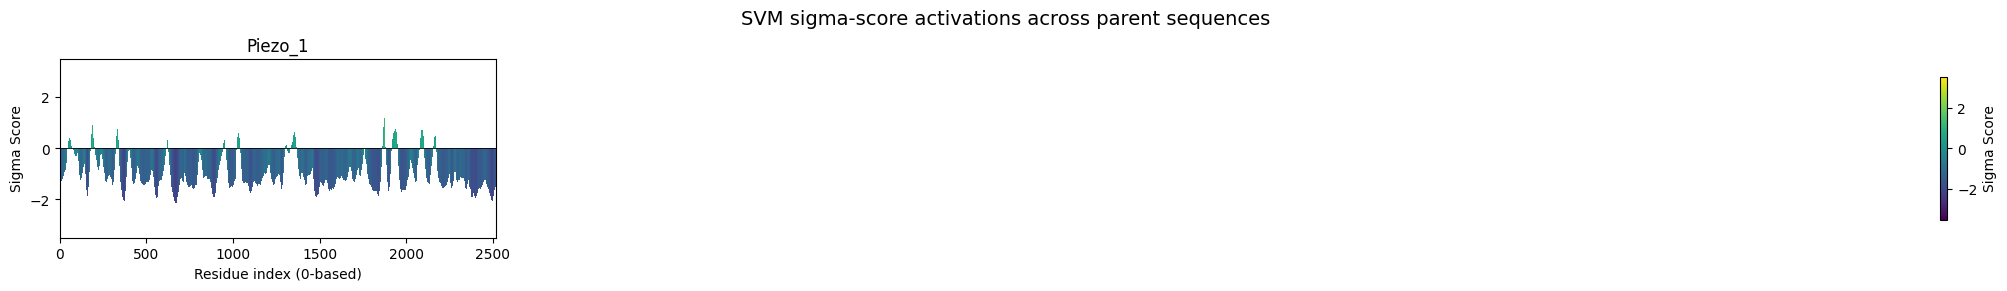

Previewed and saved 1 SVM activation graphs to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/data/test/histones/svm_sigma_heatmaps


In [6]:
window_predictions = load_window_predictions()
output_dir = _resolve_path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

parents = list(window_predictions.groupby("parent_id", sort=False))
rows = int(np.ceil(len(parents) / PREVIEW_COLUMNS))
preview, axes = plt.subplots(
    rows,
    PREVIEW_COLUMNS,
    figsize=(5.0 * PREVIEW_COLUMNS, PREVIEW_ROW_HEIGHT * rows),
    squeeze=False,
    layout="constrained",
)

color_scale = None
for axis, (parent_id, group) in zip(axes.ravel(), parents):
    sigma = sigma_profile(group)
    color_scale = draw_sigma_activation(axis, sigma, parent_label(str(parent_id), group))
    save_individual_activation(str(parent_id), group, output_dir)

for axis in axes.ravel()[len(parents):]:
    axis.set_visible(False)

if color_scale is not None:
    preview.colorbar(color_scale, ax=axes.ravel().tolist(), label="Sigma Score", shrink=0.8)
preview.suptitle("SVM sigma-score activations across parent sequences", fontsize=14)
plt.show()

if SAVE_IMAGES:
    print(f"Previewed and saved {len(parents)} SVM activation graphs to {output_dir}")
else:
    print(f"Previewed {len(parents)} SVM activation graphs (file saving disabled)")